<a href="https://colab.research.google.com/github/CPTR295/Sample-LLMs/blob/main/MultiModal_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Visual Transformers
#Tokens is patches of the image

In [2]:
#Contrastive Language Image Pre-training
#CLIP

In [20]:
from urllib.request import urlopen
from PIL import Image

puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")
caption = ["a puppy playing in snow"]

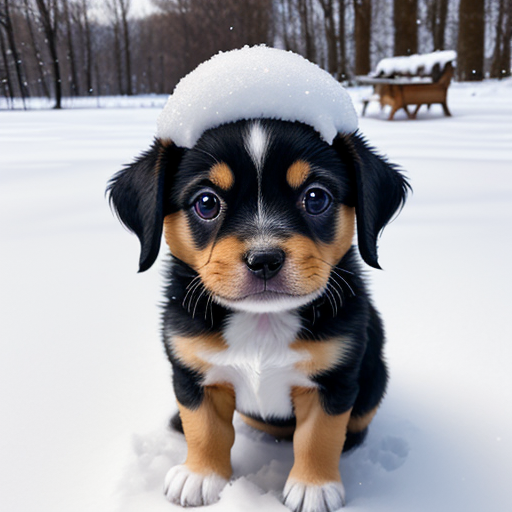

In [21]:
image

In [22]:
#A tokenizer, preprocessor, model
from transformers import CLIPTokenizerFast,CLIPProcessor,CLIPModel

In [23]:
model_id = "openai/clip-vit-base-patch32"
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)
clip_processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [28]:
inputs = clip_tokenizer(caption,return_tensors='pt')
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [29]:
clip_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'snow</w>',
 '<|endoftext|>']

In [32]:
text_embedding = model.get_text_features(**inputs)
text_embedding = text_embedding.pooler_output

print(text_embedding.shape)

torch.Size([1, 512])


In [34]:
processed_image = clip_processor(text=None,images=image,return_tensors='pt')['pixel_values']
processed_image.shape

torch.Size([1, 3, 224, 224])

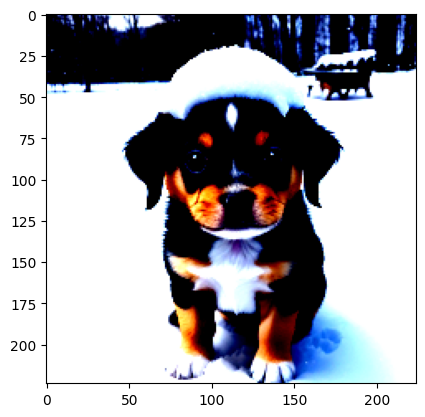

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt

img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim -1,-1,-1) )
img = np.einsum("ijk->jik",img)
plt.imshow(img)

In [37]:
image_embedding = model.get_image_features(processed_image)
image_embedding = image_embedding.pooler_output

print(image_embedding.shape)

torch.Size([1, 512])


In [38]:
#Normalize and calculate similarity

text_embedding /= text_embedding.norm(dim=-1,keepdim=True)
image_embedding /= image_embedding.norm(dim=-1,keepdim=True)

text_embedding = text_embedding.detach().cpu().numpy()
image_embedding = image_embedding.detach().cpu().numpy()

score = np.dot(text_embedding,image_embedding.T)
score

array([[0.33237153]], dtype=float32)

In [41]:
#USing SBERT
from sentence_transformers import SentenceTransformer, util

# Load SBERT-compatible CLIP model
model = SentenceTransformer('clip-ViT-B-32')

# Encode the images
image_embeddings = model.encode(image)

# Encode the captions
text_embeddings = model.encode(caption)

#Compute cosine similarities
sim_matrix = util.cos_sim(image_embeddings, text_embeddings)
print(sim_matrix)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

tensor([[0.3324]])


In [42]:
#BLIP - Bootstraping language-Image Pretraining for Unified Vision Language Underdstanding abd Generation
from transformers import AutoProcessor, Blip2ForConditionalGeneration

In [43]:
blip_processor = AutoProcessor.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    revision="51572668da0eb669e01a189dc22abe6088589a24"  # Choose specific model because of: https://huggingface.co/Salesforce/blip2-opt-2.7b/discussions/39
)
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    revision="51572668da0eb669e01a189dc22abe6088589a24",
    torch_dtype=torch.float16
)

# Send the model to GPU to speed up inference
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.96k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/127k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1248 [00:00<?, ?it/s]

Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  (qf

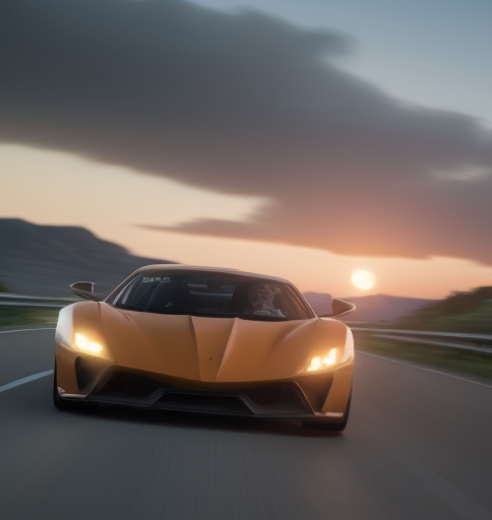

In [44]:
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
image = Image.open(urlopen(car_path)).convert("RGB")
image

In [51]:
inputs = blip_processor(images=image,return_tensors="pt").to(device,torch.float16)
inputs["pixel_values"].shape

torch.Size([1, 3, 224, 224])

In [52]:
blip_processor.tokenizer

TokenizersBackend(name_or_path='Salesforce/blip2-opt-2.7b', vocab_size=50265, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, added_tokens_decoder={
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50265: AddedToken("<image>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [55]:
text="Her vocalization was remarkably melodic"
token_ids = blip_processor(image,text=text,return_tensors="pt")
token_ids = token_ids.to(device,torch.float16)['input_ids'][0]

tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens #'G is space token

['</s>', 'Her', 'Ġvocal', 'ization', 'Ġwas', 'Ġremarkably', 'Ġmel', 'odic']

In [56]:
tokens = [token.replace("Ġ", "_") for token in tokens]
tokens

['</s>', 'Her', '_vocal', 'ization', '_was', '_remarkably', '_mel', 'odic']

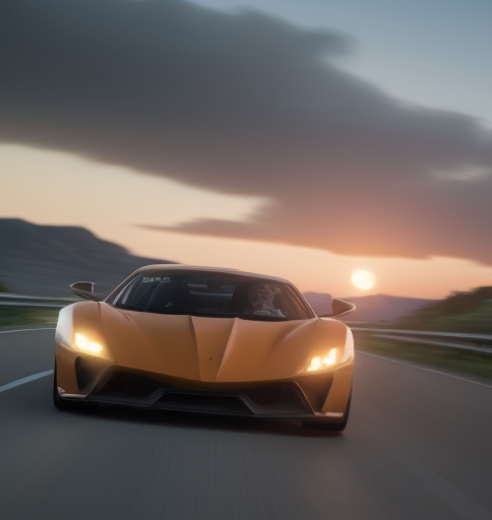

In [58]:
#Image Captioning
image = Image.open(urlopen(car_path)).convert("RGB")

inputs = blip_processor(image,return_tensors='pt').to(device,torch.float16)
image

In [61]:
inputs

{'pixel_values': tensor([[[[-1.0039, -1.0039, -0.9893,  ..., -0.0842, -0.0988, -0.0842],
          [-1.0039, -1.0039, -1.0039,  ..., -0.0696, -0.0696, -0.0696],
          [-1.0186, -1.0039, -1.0039,  ..., -0.0551, -0.0696, -0.0696],
          ...,
          [-0.9746, -0.9746, -0.9746,  ..., -0.8286, -0.8286, -0.8286],
          [-0.9746, -0.9746, -0.9746,  ..., -0.8433, -0.8286, -0.8286],
          [-0.9746, -0.9746, -0.9746,  ..., -0.8286, -0.8286, -0.8433]],

         [[-0.7915, -0.7915, -0.7915,  ...,  0.3640,  0.3640,  0.3640],
          [-0.8066, -0.7915, -0.7915,  ...,  0.3789,  0.3640,  0.3789],
          [-0.8066, -0.8066, -0.7915,  ...,  0.3789,  0.3789,  0.3789],
          ...,
          [-0.8364, -0.8364, -0.8364,  ..., -0.7764, -0.7764, -0.7617],
          [-0.8364, -0.8364, -0.8364,  ..., -0.7764, -0.7764, -0.7764],
          [-0.8364, -0.8364, -0.8364,  ..., -0.7764, -0.7764, -0.7764]],

         [[-0.4707, -0.4563, -0.4563,  ...,  0.7666,  0.7524,  0.7524],
          [-0

In [63]:
print(model.config)

Blip2Config {
  "architectures": [
    "Blip2ForConditionalGeneration"
  ],
  "dtype": "float16",
  "image_text_hidden_size": 256,
  "image_token_index": null,
  "initializer_factor": 1.0,
  "initializer_range": 0.02,
  "model_type": "blip-2",
  "num_query_tokens": 32,
  "qformer_config": {
    "add_cross_attention": false,
    "attention_probs_dropout_prob": 0.1,
    "bos_token_id": null,
    "classifier_dropout": null,
    "cross_attention_frequency": 2,
    "cross_attention_hidden_size": null,
    "decoder_start_token_id": null,
    "dtype": "float16",
    "encoder_hidden_size": 1408,
    "eos_token_id": null,
    "finetuning_task": null,
    "hidden_act": "gelu",
    "hidden_dropout_prob": 0.1,
    "hidden_size": 768,
    "initializer_range": 0.02,
    "intermediate_size": 3072,
    "is_decoder": false,
    "layer_norm_eps": 1e-12,
    "max_position_embeddings": 512,
    "model_type": "blip_2_qformer",
    "num_attention_heads": 12,
    "num_hidden_layers": 12,
    "pad_token_id": 

In [66]:
print(model.config.image_token_index)

None


In [64]:
print(type(model))
print(model.config.num_query_tokens)
print(model.config.text_config.bos_token_id)

<class 'transformers.models.blip_2.modeling_blip_2.Blip2ForConditionalGeneration'>
32
2


In [67]:
print("image_token:", getattr(blip_processor.tokenizer, "image_token", None))
print("image_token_id:", getattr(blip_processor.tokenizer, "image_token_id", None))
print("num_query_tokens:", blip_processor.num_query_tokens)
print("vocab size:", len(blip_processor.tokenizer))

image_token: None
image_token_id: None
num_query_tokens: None
vocab size: 50266


In [68]:
model.config.image_token_index = 50265
blip_processor.num_query_tokens = 32

In [62]:
generated_ids = model.generate( **inputs, max_new_tokens=20)
generated_text = blip_processor.batch_decode(generated_ids,skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

TypeError: 'NoneType' object cannot be interpreted as an integer

In [69]:
inputs = blip_processor(
    images=image,
    return_tensors="pt"
)

inputs = inputs.to(device, torch.float16)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=20
)

generated_text = blip_processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

print(generated_text[0].strip())

an orange supercar driving on the road at sunset


In [71]:
#Visual Question Answering
image = Image.open(urlopen(car_path)).convert("RGB")


In [72]:
prompt = "Question: Write down what you see in this picture. Answer:"

# Process both the image and the prompt
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

# Generate text
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

'Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset'

In [73]:
prompt = "Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer:"

# Generate output
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)
generated_text = generated_text[0].strip()
generated_text

'Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer: $1,000,000'

In [ ]:
#For two codes you can have chat like interface